In [4]:
# 3. 교육 플랫폼 사용자 이탈 예측

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
## 02. 데이터 불러오기

In [34]:
edu_df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/edu_users.csv')

In [35]:
edu_df.describe()

,rate_math,rate_science,rate_english,rate_humanities,rate_art,tot_time,age,leave_yn
count,1188.000000,1188.000000,1250.000000,1250.000000,1250.00000,1188.000000,1250.000000,1250.000000
mean,0.496497,0.499140,0.497136,0.492422,0.49503,29.708603,34.329600,0.308800
std,0.293143,0.288396,0.289979,0.286959,0.28964,10.063217,14.574241,0.462183
min,0.005000,0.002000,0.000000,0.000000,0.00400,1.000000,10.000000,0.000000
25%,0.237750,0.248500,0.247000,0.243000,0.24300,22.882500,22.000000,0.000000
50%,0.504000,0.506000,0.499500,0.484000,0.48950,29.745000,34.000000,0.000000
75%,0.753500,0.737000,0.751000,0.738000,0.74200,36.442500,47.000000,1.000000
max,0.998000,0.999000,1.000000,0.998000,0.99900,61.130000,59.000000,1.000000


In [36]:
## 3. 데이터구조 파악하기
edu_df.info() 
답02 = 4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_math        1188 non-null   float64
 1   rate_science     1188 non-null   float64
 2   rate_english     1250 non-null   float64
 3   rate_humanities  1250 non-null   float64
 4   rate_art         1250 non-null   float64
 5   tot_time         1188 non-null   float64
 6   device           1250 non-null   object 
 7   gender           1250 non-null   object 
 8   age              1250 non-null   int64  
 9   resub_yn         1250 non-null   object 
 10  comb_yn          1250 non-null   object 
 11  othersub_yn      1250 non-null   object 
 12  leave_yn         1250 non-null   int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 127.1+ KB


In [37]:
## 4. 상관관계 파악

In [38]:
corr_list = ['rate_math', 'rate_science', 'rate_english', 'rate_humanities', 'rate_art']

<Axes: >

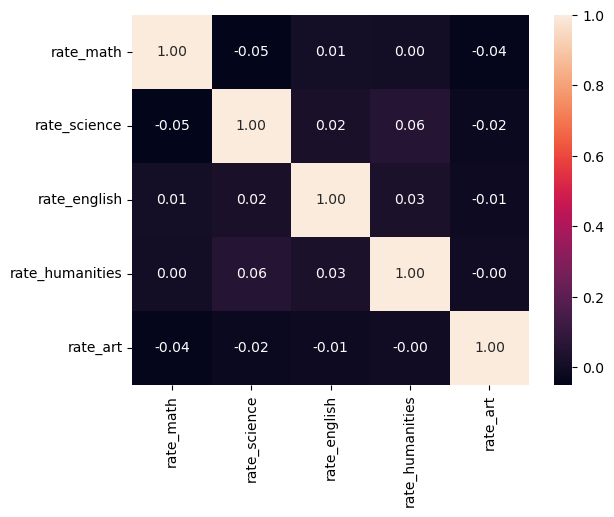

In [39]:
sns.heatmap(
    data = edu_df[corr_list].corr(), annot = True, fmt = ".2f")

In [40]:
답04 = 3

In [41]:
## 05. 데이터 시각화

<Axes: xlabel='leave_yn', ylabel='tot_time'>

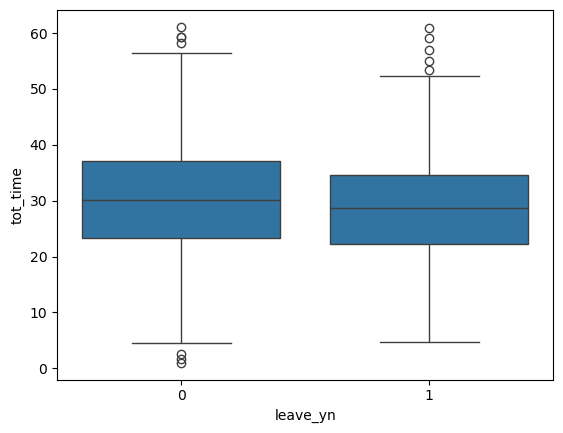

In [42]:
edu_df.groupby('leave_yn')['tot_time'].mean()
sns.boxplot(
    data = edu_df,
    x = 'leave_yn',
    y = 'tot_time')

In [43]:
답05 = 3

In [44]:
pivot_df = edu_df.pivot_table(
    index = 'leave_yn',
    values = ['rate_math', 'rate_science'],
    aggfunc = 'mean'
)

pivot_df

,rate_math,rate_science
leave_yn,,
0,0.487965,0.496375
1,0.515511,0.505424


In [45]:
## 07. 결측치 처리

In [51]:
edu_df['rate_math'] = edu_df['rate_math'].fillna(edu_df['rate_math'].mean())

In [56]:
edu_df['rate_science'] = edu_df['rate_science'].fillna(edu_df['rate_science'].median())
edu_df['tot_time'] = edu_df['tot_time'].fillna(edu_df['tot_time'].mode()[0])

In [57]:
(edu_df['tot_time'].isna().sum())

np.int64(0)

In [58]:
edu_df

,rate_math,rate_science,rate_english,rate_humanities,rate_art,tot_time,device,gender,age,resub_yn,comb_yn,othersub_yn,leave_yn
0,0.375,0.797,0.828,0.896,0.394,17.09,mobile,M,30,N,N,Y,1
1,0.951,0.482,0.765,0.909,0.473,28.57,tablet,F,25,N,Y,N,1
2,0.732,0.117,0.574,0.314,0.855,40.97,tablet,F,24,N,N,N,0
3,0.599,0.125,0.956,0.691,0.340,8.09,mobile,M,14,Y,N,N,1
4,0.156,0.686,0.200,0.272,0.870,45.34,tablet,F,15,Y,N,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.626,0.492,0.212,0.897,0.607,16.80,pc,M,24,Y,N,Y,0
1246,0.131,0.577,0.664,0.119,0.167,33.37,tablet,F,40,N,N,N,0
1247,0.033,0.866,0.411,0.328,0.797,27.37,mobile,M,23,N,N,N,0
1248,0.921,0.981,0.402,0.816,0.720,21.39,pc,F,23,Y,N,Y,0


In [59]:
## 08. 데이터 분리

In [61]:
Feature = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
Target = edu_df['leave_yn']

In [63]:
from sklearn.model_selection import train_test_split

In [65]:
X_train, X_valid, y_train, y_valid = train_test_split(Feature, Target, test_size = 0.2, random_state = 42)

In [66]:
## 09.데이터 스케일링

In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [68]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit(X_valid)

In [69]:
## 10. 분류모델 사용

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rfc = RandomForestClassifier(n_estimators = 150, max_depth = 7, min_samples_split = 5, random_state = 42)

In [74]:
rfc.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
## 11. XGBoost

In [76]:
from xgboost import XGBClassifier

In [77]:
xgbc = XGBClassifier(n_estimators = 200, max_depth = 5, learning_rate = 0.1, random_state = 42)

In [78]:
xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [79]:
## 12. 성능 검증

In [81]:
from sklearn.metrics import accuracy_score, f1_score

In [83]:
rfc_predict = rfc.predict(X_valid)
xgbc_predict = xgbc.predict(X_valid)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [84]:
print('rfc_accuray score :', accuracy_score(y_valid, rfc_predict))
print('rfc f1-score: ', f1_score(y_valid, rfc_predict))
print('xgbc accuracy score :', accuracy_score(y_valid, xgbc_predict))
print('xgbc f1-score : ', f1_score(y_valid, xgbc_predict))

rfc_accuray score : 0.38
rfc f1-score:  0.41509433962264153
xgbc accuracy score : 0.64
xgbc f1-score :  0.11764705882352941


In [86]:
답12 = 'XGBC'

In [87]:
## 13. 이탈 여부 예측 딥러닝

In [90]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(10)

In [95]:
model = Sequential()
print(X_train.shape)

(1000, 4)


In [100]:
model.add(Dense(64, activation = 'selu', input_shape = (X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation = 'selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation = 'selu'))
model.add(Dense(1, activation = 'sigmoid'))

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [103]:
model.fit(
    X_train, y_train,
    epochs = 45,
    batch_size = 32,
)

Epoch 1/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5550 - loss: 0.7171
Epoch 2/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6750 - loss: 0.6290
Epoch 3/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6890 - loss: 0.6187
Epoch 4/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6940 - loss: 0.6134
Epoch 5/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6950 - loss: 0.6082
Epoch 6/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: 0.6043
Epoch 7/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6970 - loss: 0.6008
Epoch 8/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - loss: 0.5988
Epoch 9/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - loss: 0.5968
Epoch 10/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7000 - loss: 0.5951
Epoch 11/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - loss: 0.5935
Epoch 12/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6990 - lo

In [104]:
simul_data = np.array([[0.3, 0.5, 0.7, 120]])

In [105]:
## 12. 입력 데이터 예측

In [106]:
deep_pre = model.predict(simul_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


In [107]:
deep_pre

array([[0.9993397]], dtype=float32)

In [108]:
np.where(deep_pre >= 0.5, 1, 0)

array([[1]])